In [22]:
import pandas as pd 
import numpy as np 
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

Introduction

This project performs Exploratory Data Analysis (EDA) on coffee sales data to identify key patterns in customer behavior, product demand, and sales trends. Using Python tools like Pandas and visualization libraries, the analysis helps uncover insights that can improve business decisions, such as pricing, inventory management, and sales strategies.

Objectives
+ To analyze coffee sales data and understand overall sales trends
+ To identify top-selling products and customer preferences
+ To study sales patterns based on time (daily, monthly, seasonal)
+ To examine relationships between variables like price, quantity, and revenue
+ To generate insights that help improve business decisions and profitability

In [5]:
df= pd.read_csv("/Users/bhavna daud/Downloads/Coffe_sales.csv")
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


In [6]:
df.shape

(3547, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [8]:
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [9]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3542    False
3543    False
3544    False
3545    False
3546    False
Length: 3547, dtype: bool

In [11]:


# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

# Check duplicates
print(df.duplicated().sum())

# Optional: drop duplicates
df = df.drop_duplicates()

0


In [12]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,2026-04-16 10:15:50.520
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,2026-04-16 12:19:22.539
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,2026-04-16 12:20:18.089
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,2026-04-16 13:46:33.006
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,2026-04-16 13:48:14.626


# Univariate analysis 

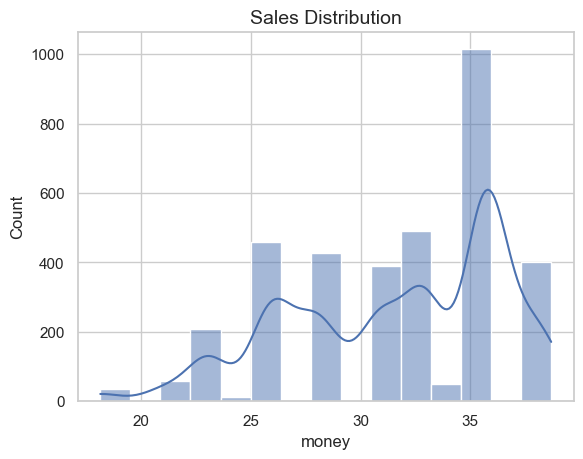

In [23]:
#1. sales Distribution 
plt.figure()
sns.histplot(df['money'], bins=15, kde=True)
plt.title("Sales Distribution", fontsize=14)
plt.show()


+ Most of the sales are ranges in between 30-35 rupees
+ Few are at very low or very high values
+ the curve shows a normal like distribution
+ So we can say that Most transection fall in a fixed price range, indication standardized pricing of coffee items 

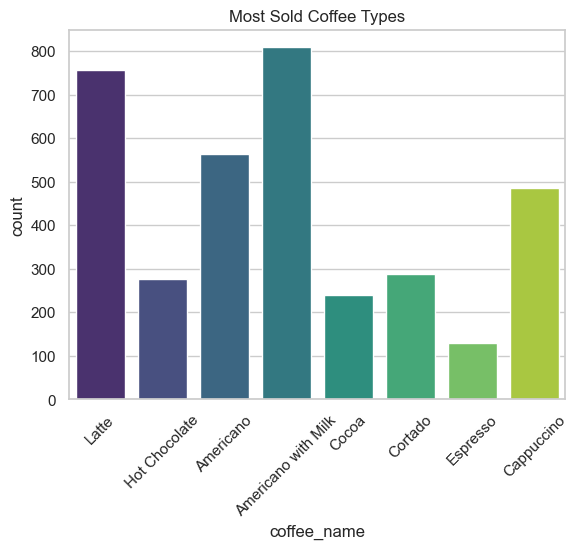

In [24]:
#2. coffee popularity
plt.figure()
sns.countplot(x='coffee_name', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Most Sold Coffee Types")
plt.show()

+ Americano with milk and Latte have highest sales as compared to other.
+ Espresso has lowest demand
+ so we can say that milk based coffees are more preferred, while espresso has lower demand, possibly due to taste preference

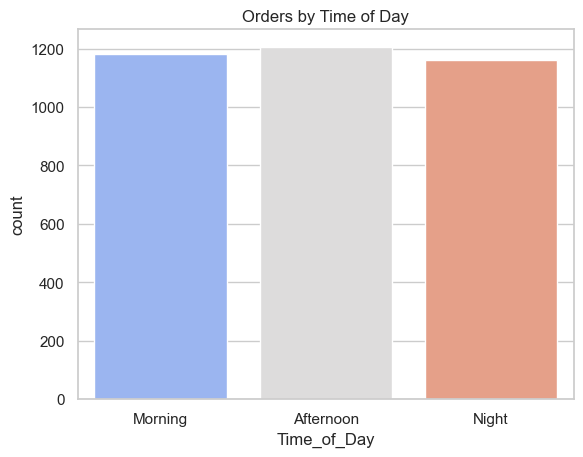

In [25]:
#3.Time of Day Orders
plt.figure()
sns.countplot(x='Time_of_Day', data=df, palette='coolwarm')
plt.title("Orders by Time of Day")
plt.show()

+ Sales of coffee are high in afternoon as compared to morning and night.
+ so we can say that customer demand more coffee in Afternoon and indicating peak during Afternoon.

# Bivariate analysis 

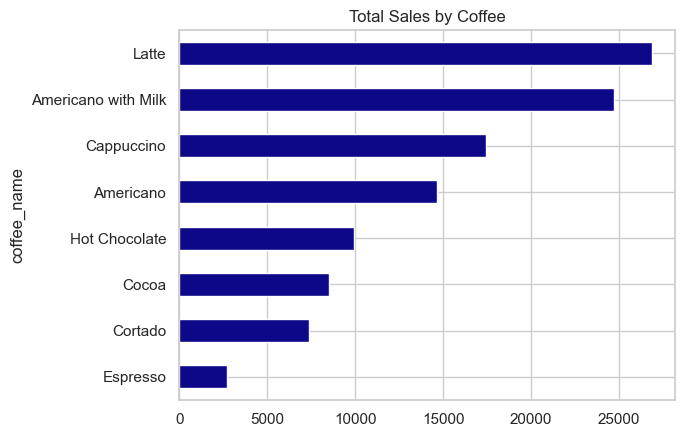

In [26]:
#1.Sales by Coffee Type
plt.figure()
df.groupby('coffee_name')['money'].sum().sort_values().plot(
    kind='barh', colormap='plasma'
)
plt.title("Total Sales by Coffee")
plt.show()

+ Revenue Generated by each coffee
+ Latte have generated highest revenue i.e more than 25000
+ after that americano with milk coffee have generated revenue about 24000
+ So milk based coffee generate highest revenue as compared to the other coffee.
+ milk based coffee are key products for the business.

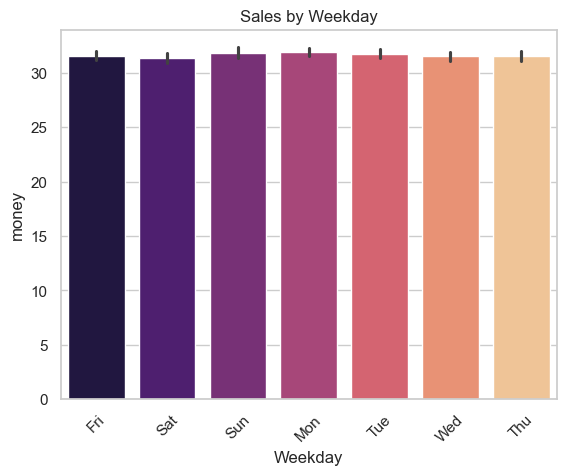

In [27]:
#Sales by Weekday
plt.figure()
sns.barplot(x='Weekday', y='money', data=df, palette='magma')
plt.xticks(rotation=45)
plt.title("Sales by Weekday")
plt.show()

+ According to the plots monday have highest coffee sales
+ friday and saturday have less sales of coffee as compared to other days.
+ this indicates customer behaviour pattern

# Multivariate analysis 

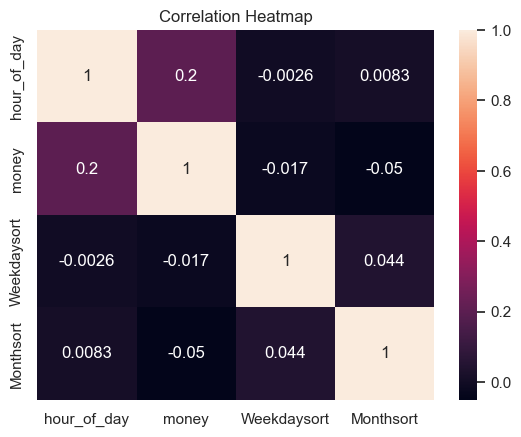

In [28]:
# Heatmap (correlation)
plt.figure()
sns.heatmap(df[['hour_of_day','money','Weekdaysort','Monthsort']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


1. Hour_of_day vs Money = 0.2 ( Weak Positive correlation)
   AS time increases sales slightly increases

2. hour_of_day vs Weekdaysort → -0.0026 (Almost Zero Correlation)
   Time of purchase is independent of the day of the week

3. hour_of_day vs Monthsort → 0.0083 ( No correlation)
   No seasonal effect on hourly purchase behavior

